In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
plt.figure(figsize = (10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [9]:
df = pd.read_csv("demand_forecasting.csv")

In [10]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [11]:
df.dtypes

,0
Date,object
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df.dtypes

,0
Date,datetime64[ns]
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [15]:
df.isna().sum().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


In [22]:
df.describe(include="object")

,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
count,76000,76000,76000,76000,76000,76000
unique,5,20,5,4,4,4
top,S001,P0001,Groceries,North,Cloudy,Winter
freq,15200,3800,30400,30400,24360,21000


In [24]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [28]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekDay"] = df["Date"].dt.day_name()

In [33]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'WeekDay',
       'Discounted Price'],
      dtype='object')

In [31]:
df["Discounted Price"] = df["Price"] * ( 1 - df["Discount"] / 100)

In [32]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,0,32.23,Winter,0,64,2024,1,30,Tuesday,28.310
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,0,40.73,Winter,0,137,2024,1,30,Tuesday,40.774
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,0,19.41,Winter,0,68,2024,1,30,Tuesday,16.029
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,0,143.71,Winter,0,84,2024,1,30,Tuesday,151.720


In [34]:
df["Sell through Rate"] = df["Units Sold"] / df["Inventory Level"]

In [35]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [36]:
df["Sell through Rate"].describe()

,Sell through Rate
count,75594.000000
mean,0.437580
std,0.298007
min,0.003150
25%,0.190807
50%,0.350475
75%,0.642276
max,1.000000


In [37]:
df.groupby("Category")["Demand"].agg(["mean","sum","std"]).sort_values(by = "sum", ascending = False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Furniture,73.581140,1006590,32.336141
Toys,92.606955,985338,46.170390
Electronics,97.482018,889036,40.557859


In [40]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [41]:
df.groupby("Promotion")["Demand"].mean()

,Demand
Promotion,
0,95.026843
1,123.269400


In [42]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [43]:
pd.pivot_table(df, values = "Demand",index = "Month", columns = "Category", aggfunc="mean" )

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


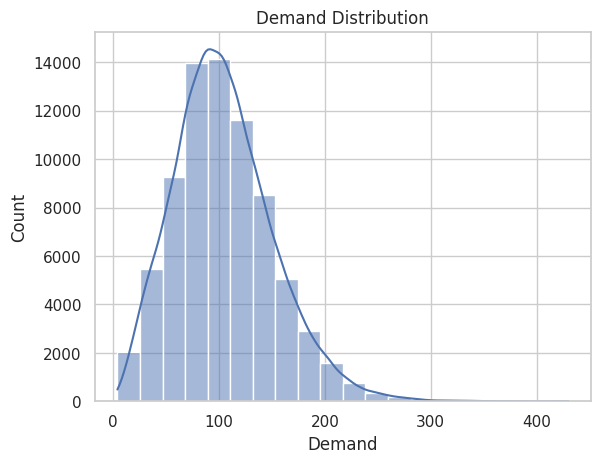

In [44]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Demand Distribution")
plt.show()

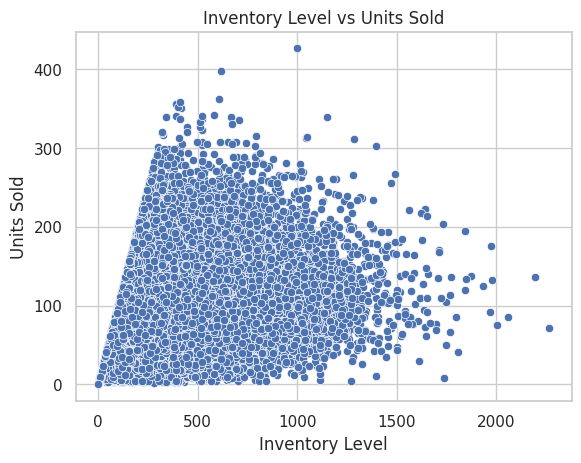

In [45]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory Level vs Units Sold")
plt.show()

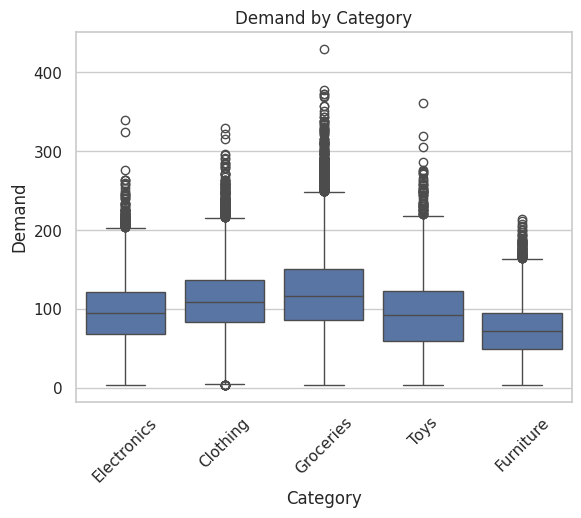

In [46]:
sns.boxplot(data  = df, x = "Category", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Category")
plt.show()

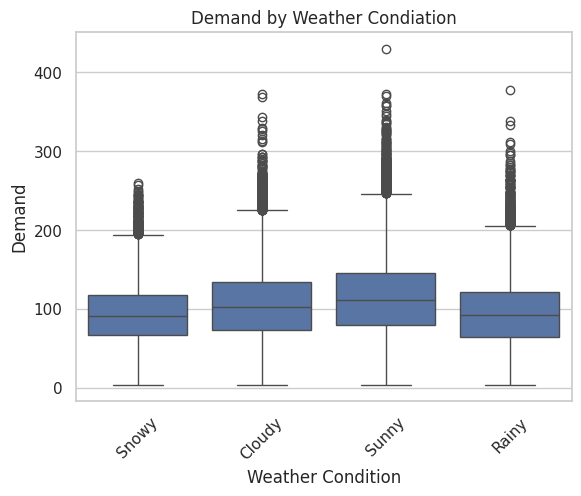

In [49]:
sns.boxplot(data  = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Weather Condiation")
plt.show()

In [50]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [52]:
monthly_demand = df.groupby("Month")["Demand"].mean()

In [53]:
monthly_demand

,Demand
Month,
1,106.040000
2,92.882500
3,113.613871
4,92.816667
5,86.521129
6,117.346000
7,101.561613
8,119.803387
9,107.431500


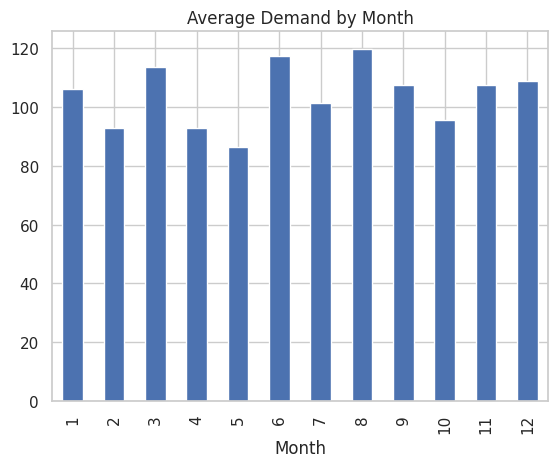

In [54]:
monthly_demand.plot(kind = "bar")
plt.title("Average Demand by Month")
plt.show()

In [55]:
daily_demand = df.groupby("Date")["Demand"].sum()

In [56]:
daily_demand

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724
...,...
2024-01-26,11182
2024-01-27,11540
2024-01-28,11440


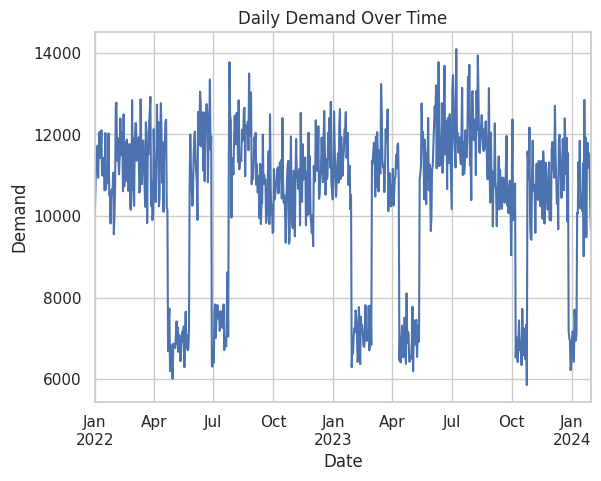

In [57]:
daily_demand.plot()
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

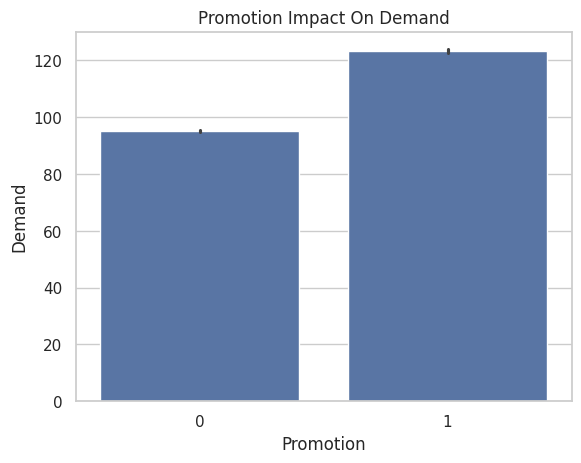

In [58]:
sns.barplot(data = df, x = "Promotion", y = "Demand")
plt.title("Promotion Impact On Demand")
plt.show()

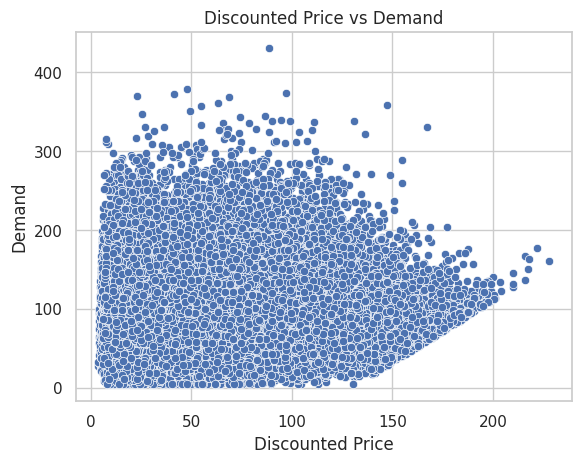

In [60]:
sns.scatterplot(data = df, x = "Discounted Price", y = "Demand")
plt.title("Discounted Price vs Demand")
plt.show()


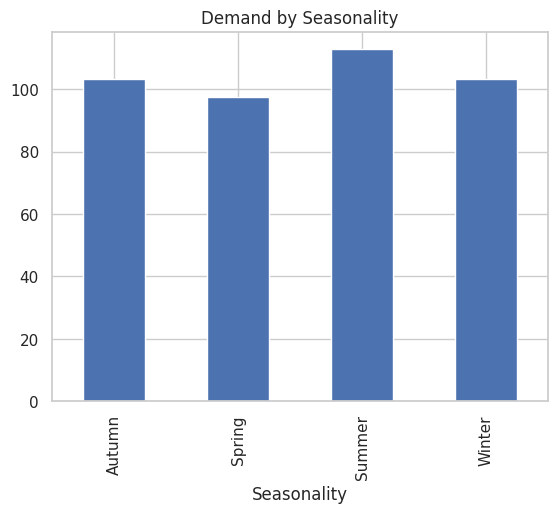

In [61]:
df.groupby("Seasonality")["Demand"].mean().plot(kind = "bar", title = "Demand by Seasonality")
plt.show()

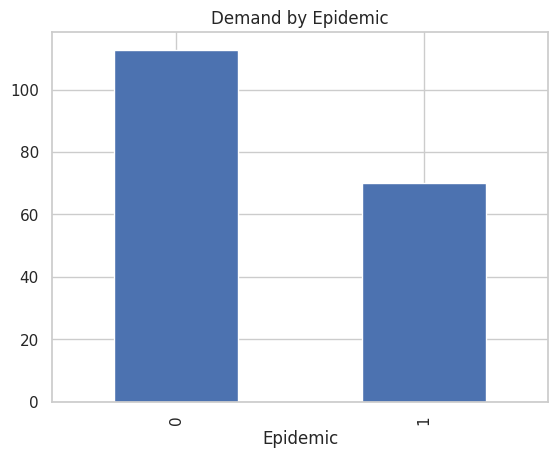

In [62]:
df.groupby("Epidemic")["Demand"].mean().plot(kind = "bar", title = "Demand by Epidemic")
plt.show()

In [64]:
df.to_csv("demand_forecasting_preprocessed.csv", index = False)

In [67]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor

import pickle

In [68]:
df = pd.read_csv("demand_forecasting.csv")

In [69]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [70]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [71]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Category",
    "Promotion",
    "Competitor Pricing"
]

In [72]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Category',
 'Promotion',
 'Competitor Pricing']

In [73]:
target = "Demand"

In [74]:
X = df[features].copy()

In [75]:
X

,Price,Discount,Inventory Level,Category,Promotion,Competitor Pricing
0,72.72,5,195,Electronics,0,85.73
1,80.16,15,117,Clothing,1,92.02
2,62.94,10,247,Clothing,1,60.08
3,87.63,10,139,Electronics,0,85.19
4,54.41,0,152,Groceries,0,51.63
...,...,...,...,...,...,...
75995,29.80,5,233,Toys,0,32.23
75996,42.92,5,137,Toys,0,40.73
75997,17.81,10,197,Clothing,0,19.41
75998,151.72,0,125,Furniture,0,143.71


In [76]:
Y = df[target]

In [77]:
Y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


In [78]:
X

,Price,Discount,Inventory Level,Category,Promotion,Competitor Pricing
0,72.72,5,195,Electronics,0,85.73
1,80.16,15,117,Clothing,1,92.02
2,62.94,10,247,Clothing,1,60.08
3,87.63,10,139,Electronics,0,85.19
4,54.41,0,152,Groceries,0,51.63
...,...,...,...,...,...,...
75995,29.80,5,233,Toys,0,32.23
75996,42.92,5,137,Toys,0,40.73
75997,17.81,10,197,Clothing,0,19.41
75998,151.72,0,125,Furniture,0,143.71


In [79]:
label_encoders = {}
categorical_cols = X.select_dtypes(include = ["object"]).columns

In [80]:
categorical_cols

Index(['Category'], dtype='object')

In [81]:
for col in categorical_cols:
  le = LabelEncoder()
  X[col] = le.fit_transform(X[col])
  label_encoders[col] = le

In [82]:
label_encoders

{'Category': LabelEncoder()}

In [83]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [84]:
X

,Price,Discount,Inventory Level,Category,Promotion,Competitor Pricing
0,72.72,5,195,1,0,85.73
1,80.16,15,117,0,1,92.02
2,62.94,10,247,0,1,60.08
3,87.63,10,139,1,0,85.19
4,54.41,0,152,3,0,51.63
...,...,...,...,...,...,...
75995,29.80,5,233,4,0,32.23
75996,42.92,5,137,4,0,40.73
75997,17.81,10,197,0,0,19.41
75998,151.72,0,125,2,0,143.71


In [86]:
xgb = XGBRegressor(objective = "reg:squarederror", n_jobs = -1)

In [88]:
param_dict = {
    "n_estimators" : [200, 300,500],
    "max_depth" : [3,4,6,8],
    "subsample" : [0.7,0.8,1.0],
    "learning_rate" : [0.01, 0.05, 0.1],
    "min_child_weight" : [1,3,5],
    "colsample_bytree" : [0.7,0.8,1.0]
}

In [90]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions= param_dict,
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [93]:
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error', verbose=1)

In [94]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [95]:
best_model = random_search.best_estimator_

In [96]:
Y_pred = best_model.predict(X_test)

In [100]:
np.sqrt(mean_squared_error(Y_test, Y_pred))

np.float64(35.411343618054616)

In [101]:
best_model.feature_importances_

array([0.05573072, 0.01482144, 0.01321047, 0.23342206, 0.66488695,
       0.01792832], dtype=float32)

In [103]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

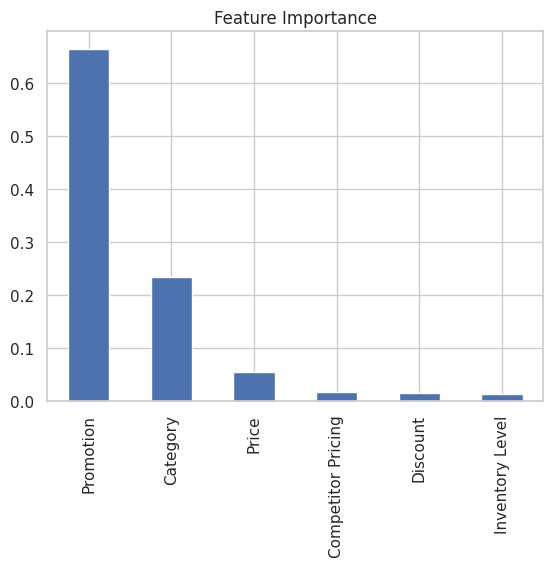

In [105]:
feature_importance.plot(kind = "bar", title = "Feature Importance")
plt.show()

In [106]:
with open("label_encoders.pkl", "wb") as f:
  pickle.dump(label_encoders, f)

In [110]:
with open("xgb_model.pkl", "wb") as f:
  pickle.dump(best_model, f)

In [120]:
!pip install streamlit

In [121]:
!mkdir -p /content/demand_forecasting

In [122]:
!mv /content/app.py /content/demand_forecasting/
!mv /content/xgb_model.pkl /content/demand_forecasting/
!mv /content/label_encoders.pkl /content/demand_forecasting/

In [123]:
!zip -r /content/demand_forecasting.zip /content/demand_forecasting

  adding: content/demand_forecasting/ (stored 0%)
  adding: content/demand_forecasting/label_encoders.pkl (deflated 19%)
  adding: content/demand_forecasting/app.py (deflated 60%)
  adding: content/demand_forecasting/xgb_model.pkl (deflated 69%)


In [124]:
from google.colab import files
files.download("/content/demand_forecasting.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>